# Failure recovery and operational runbooks

CPU companion; no accelerator is required. TPU execution not validated.

- Rehearse a real worker failure and resume from an atomic complete-state checkpoint.
- Verify the next update and every later state against an uninterrupted reference.
- Reject corrupted or incompatible recovery artifacts and record a usable runbook.

A restarted job reaches a plausible final loss, but did it continue the same experiment? We will force a worker to fail after an uncheckpointed update, restore its last committed state, and compare every subsequent update with an uninterrupted run. A matching final metric alone will not be accepted as recovery evidence.

## The idea

Recovery is a state transition, not a second invocation with the same seed. A complete state includes parameters, optimizer momentum, random key, completed step and provenance for the code, configuration and dataset. The checkpoint represents a precise boundary before the next sampled minibatch. After restore, the next key split, batch, loss and update must match the original continuation.

## Identify the boundary before issuing a retry

The default job checkpoints after even-numbered updates. We inject failure after update $3$, leaving a committed checkpoint at step $2$. The runbook first confirms that the failed child is gone, preserves its events, then reads and validates that checkpoint. Blindly restarting from the beginning would repeat more work; continuing from the progress counter $3$ with checkpoint state $2$ would skip a state transition.

## Momentum is part of the experiment

For gradient $g_t$, velocity follows $v_{t+1}=\beta v_t+g_t$, and parameters follow $\theta_{t+1}=\theta_t-\alpha v_{t+1}$. Restoring only parameters sets the wrong velocity for the next step. Likewise, reseeding the generator returns to earlier minibatches instead of continuing the saved key. The serialized key is the actual legacy uint32 key array used by this worker, not a guessed integer seed.

$$
v_{t+1}=\beta v_t+g_t,\qquad \theta_{t+1}=\theta_t-\alpha v_{t+1}
$$

## Write the complete artifact before selecting it

The worker serializes state and its checksum into a sibling pending file, flushes and fsyncs the file, then uses os.replace to select it as the checkpoint. Readers see either the old complete file or the new complete file under the local filesystem’s replace contract. This avoids selecting a half-written JSON payload. It does not prove survival of a machine power loss or atomic behavior on an arbitrary remote filesystem; directory synchronization and storage-specific guarantees would need separate validation.

## Compatibility is more than array shape

The checkpoint includes schema version, data hash, training-configuration hash and worker-source hash. Restore checks these before accepting values, then checks parameter, velocity and key shapes and finite numeric state. A checksum detects accidental payload corruption; it is not a signature against an adversary who can edit both state and checksum. Operational controls such as failure injection and total requested steps are excluded from the training hash so a compatible retry can finish the intended work.

## Prove the continuation at the next update

The first restored progress event is update $3$, and its full-state hash must equal update $3$ from the uninterrupted run. We compare every remaining update and the final checkpoint, not only the final parameters. Wall-clock timestamps and timing samples should differ; they are observability metadata, not deterministic training state. Exact replay is bounded to this pinned CPU example, not promised across changed JAX versions or accelerator kernels.

## Write a runbook from the failed drill

Use the actual trace: confirm process exit; preserve logs; find the latest committed step; validate checksum and provenance; restore into a single writer; verify the first new update; continue and compare completion artifacts. Escalate an incompatible checkpoint instead of silently deleting fields or relaxing checks. A failed rehearsal is useful evidence about the runbook, whereas an untested list of commands is only a proposal.

## Create the local artifact helpers

Create main.py with this block. Run python3 main.py in the CPU course environment.

In [1]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

The only filesystem writes are to the caller-selected run directory. Stable JSON encoding makes hashes reproducible.

## Define the supervised worker

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [2]:
# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

The string is a real Python program launched in a separate process. It emits structured events, synchronizes JAX updates and preserves complete state.

## Add bounded launch and result collection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [3]:
def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

The supervisor owns the child handle, captures its output and always waits for termination after a timeout.

## Rehearse a failure and verify every resumed update

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [4]:
with tempfile.TemporaryDirectory(prefix='ops-recovery-') as folder:
    base=Path(folder)
    uninterrupted=launch(base/'full')
    failed=launch(base/'resume',dict(fail_after=3))
    committed=json.loads((base/'resume'/'checkpoint.json').read_text())
    assert committed['step']==2
    resumed=launch(base/'resume',dict(resume=True))
    final_full=json.loads((base/'full'/'checkpoint.json').read_text())
    final_resumed=json.loads((base/'resume'/'checkpoint.json').read_text())
assert failed['status']=='failed' and resumed['status']=='completed'
assert final_full==final_resumed
full_events={e['step']:e for e in uninterrupted['events'] if e['event']=='progress'}
resume_events=[e for e in resumed['events'] if e['event']=='progress']
assert [e['step'] for e in resume_events]==[3,4,5,6,7,8]
assert all(e['state_hash']==full_events[e['step']]['state_hash'] for e in resume_events)
print('restored step:',committed['step'],'replayed updates:',[e['step'] for e in resume_events])
print('all next-update state hashes match:',final_full==final_resumed)

restored step: 2 replayed updates: [3, 4, 5, 6, 7, 8]
all next-update state hashes match: True


All files stay inside one temporary drill directory; the two runs have independent output paths.

## Run the example

In [5]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

with tempfile.TemporaryDirectory(prefix='ops-recovery-') as folder:
    base=Path(folder)
    uninterrupted=launch(base/'full')
    failed=launch(base/'resume',dict(fail_after=3))
    committed=json.loads((base/'resume'/'checkpoint.json').read_text())
    assert committed['step']==2
    resumed=launch(base/'resume',dict(resume=True))
    final_full=json.loads((base/'full'/'checkpoint.json').read_text())
    final_resumed=json.loads((base/'resume'/'checkpoint.json').read_text())
assert failed['status']=='failed' and resumed['status']=='completed'
assert final_full==final_resumed
full_events={e['step']:e for e in uninterrupted['events'] if e['event']=='progress'}
resume_events=[e for e in resumed['events'] if e['event']=='progress']
assert [e['step'] for e in resume_events]==[3,4,5,6,7,8]
assert all(e['state_hash']==full_events[e['step']]['state_hash'] for e in resume_events)
print('restored step:',committed['step'],'replayed updates:',[e['step'] for e in resume_events])
print('all next-update state hashes match:',final_full==final_resumed)

restored step: 2 replayed updates: [3, 4, 5, 6, 7, 8]
all next-update state hashes match: True


Expected: The failure leaves checkpoint step $2$. Resuming replays steps $3$ through $8$, and every complete-state hash plus the final checkpoint matches uninterrupted execution.

## Resumed loss follows the same continuation

Predict: Should timing and loss both match after a restart?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [6]:
visual_data={'kind':'line','x':list(range(3,9)),'xlabel':'completed training step','ylabel':'sampled minibatch mean squared error','series':[{'label':'uninterrupted continuation','y':[full_events[i]['loss'] for i in range(3,9)]},{'label':'restored continuation (overlaps)','y':[e['loss'] for e in resume_events]}]}

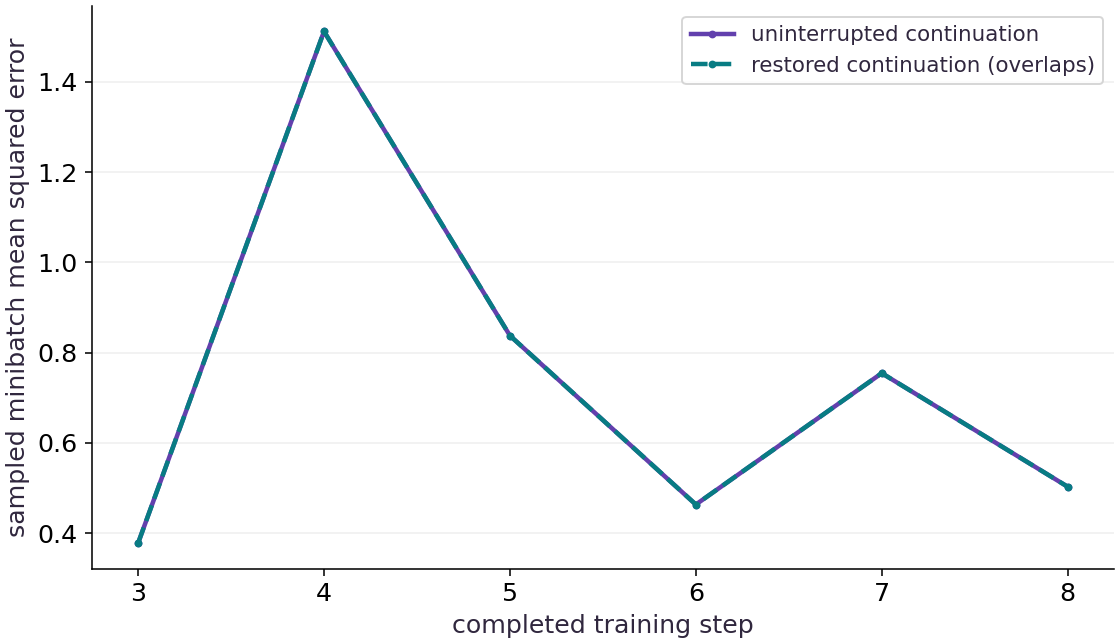

In [7]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is completed training step; the vertical axis is that update’s sampled minibatch mean squared error. The plot zooms in on updates $3$ through $8$. Both lines cover that continuation, because the restored boundary was step $2$; the first two uninterrupted updates are outside this plotted interval. Its points lie on top of the uninterrupted points for the remaining updates. In the recorded run, loss rises from about $0.38$ at update $3$ to $1.51$ at update $4$, falls to about $0.46$ at update $6$, and rises again near $0.75$ at update $7$. Both executions share those same changes. The visible rebounds therefore do not indicate a restore mismatch.

### Connect it to the computation

The overlap is supported by equality checks of the complete state hashes, not inferred merely from a visually similar curve. The loss can move unevenly because each update samples a minibatch. Restart timing is deliberately absent: compilation, process startup and checkpoint reading add overhead even when the numerical continuation is exact.

## Compare state, not only loss

Predict: Could two different states have the same current loss?

In [8]:
for event in resume_events:
    original=full_events[event['step']]
    assert event['state_hash']==original['state_hash']
    assert event['loss']==original['loss']
assert all(name in committed for name in ['params','velocity','key','step','data_hash','config_hash','worker_hash'])

Expected: All state fields and later hashes support the continuation claim.

Loss is a scalar projection of a much larger state; equal loss alone would not prove the next update is correct.

## Reject a changed training rule

Predict: Should a learning-rate change be silently accepted as an exact resume?

In [9]:
with tempfile.TemporaryDirectory() as folder:
    launch(folder,dict(steps=4))
    incompatible=launch(folder,dict(steps=8,resume=True,learning_rate=.05))
assert incompatible['status']=='failed'
assert any(e['event']=='failed' and 'provenance' in e['message'] for e in incompatible['events'])

Expected: Restore rejects the incompatible training configuration.

A deliberate branch experiment is valid when explicitly labeled, but it is not the same-run recovery being tested here.

## Your exercise

Repeat the recovery drill with seed $9$, checkpoint cadence $3$ and failure after update $5$. Verify restoration at step $3$ and equality with a matching uninterrupted run.

In [10]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [11]:
with tempfile.TemporaryDirectory() as folder:
    base=Path(folder); cfg=dict(seed=9,checkpoint_every=3)
    ref=launch(base/'ref',cfg)
    broken=launch(base/'broken',dict(cfg,fail_after=5))
    cp=json.loads((base/'broken'/'checkpoint.json').read_text())
    assert cp['step']==3
    fixed=launch(base/'broken',dict(cfg,resume=True))
    assert fixed['status']=='completed'
    assert json.loads((base/'ref'/'checkpoint.json').read_text())==json.loads((base/'broken'/'checkpoint.json').read_text())

## Reject accidental checkpoint corruption · Transfer / diagnosis

After saving a checkpoint, alter one momentum value without updating its checksum, then attempt to restore.

Hint: The expected outcome is a failed restore; preserve the failure event.

In [12]:
# Write your attempt here.

## Reference reasoning

Rejecting corruption is safer and more inspectable than treating plausible parameter values as evidence of a valid checkpoint.

In [13]:
with tempfile.TemporaryDirectory() as folder:
    launch(folder,dict(steps=4))
    path=Path(folder)/'checkpoint.json'; state=json.loads(path.read_text())
    state['velocity'][0]+=1.;path.write_text(json.dumps(state))
    bad=launch(folder,dict(resume=True))
assert bad['status']=='failed'
assert any(e['event']=='failed' and 'checksum' in e['message'] for e in bad['events'])

## Explain a weights-only mismatch by hand · Transfer / diagnosis

Let saved velocity be $2$, the next gradient $3$, momentum $0.8$, and learning rate $0.1$. Compare the correct parameter decrement with a reset-momentum decrement.

Hint: Apply the recurrence before multiplying by the learning rate.

In [14]:
# Write your attempt here.

## Reference reasoning

The next loss could initially look close, but the state transition has already changed.

In [15]:
correct=.1*(.8*2+3)
weights_only=.1*3
assert abs(correct-.46)<1e-12 and abs(weights_only-.3)<1e-12
assert abs(correct-weights_only-.16)<1e-12

## Checkpoint

Which evidence most directly supports a correct resume?

1. The process prints started again
2. The next and later complete training states match a compatible uninterrupted run
3. The final loss is finite

## Diagnose

When replay diverges immediately, compare saved key, momentum, step and data/config/source hashes before changing numerical tolerances. When restore rejects a checksum, retain the artifact for diagnosis rather than rewriting its checksum. When two workers target one checkpoint directory, stop the duplicate writer before continuing.

## Evidence

Keep the injected failure timeline, accepted checkpoint identity and full-state comparisons for every resumed update. Record the incompatible and corrupted restore rejections.

## Carry forward

- A checkpoint is a precise state boundary, including optimizer and randomness.
- A runbook becomes evidence only after a controlled failure and verified recovery.

## Primary references

- [Python subprocess management](https://docs.python.org/3/library/subprocess.html)
- [Python os.replace and fsync](https://docs.python.org/3/library/os.html#os.replace)
- [JAX asynchronous dispatch and synchronization](https://docs.jax.dev/en/latest/async_dispatch.html)
- [JAX device discovery](https://docs.jax.dev/en/latest/_autosummary/jax.devices.html)